# 🧠 Week 6 — Convolutional Denoising Autoencoder on MNIST
**Author:** Atharva Hon  
**Objective:** Build a deep convolutional autoencoder that learns to reconstruct clean MNIST digit images from their Gaussian-noise-corrupted counterparts.  
**Dataset:** Local `mnist_png/` directory (grayscale 28×28 PNGs, digits 0–9).  
**Framework:** TensorFlow / Keras (Functional API)

---
## § 1 · Imports & Environment Setup

In [17]:
# ── Standard library ──────────────────────────────────────────────
import time
from pathlib import Path

# ── Numerical / image processing ──────────────────────────────────
import numpy as np
from PIL import Image

# ── Visualization ─────────────────────────────────────────────────
import matplotlib.pyplot as plt

# ── TensorFlow / Keras ────────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, UpSampling2D
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# ── Reproducibility seed ──────────────────────────────────────────
SEED_VALUE = 42
np.random.seed(SEED_VALUE)
tf.random.set_seed(SEED_VALUE)

print(f"TensorFlow version : {tf.__version__}")
print(f"NumPy version      : {np.__version__}")
print("Environment ready. ✔")

Configuration loaded. ✔


---
## § 2 · Configuration Constants
All tuneable hyper-parameters are gathered here so nothing is hard-coded deeper in the notebook.

In [18]:
# ── Paths (pathlib, relative to notebook) ─────────────────────────
DATASET_ROOT    = Path("mnist_png")
TRAIN_DIR       = DATASET_ROOT / "training"
TEST_DIR        = DATASET_ROOT / "testing"
BEST_MODEL_PATH = Path("best_denoiser.keras")

# ── Image parameters ──────────────────────────────────────────────
IMG_HEIGHT   = 28
IMG_WIDTH    = 28
IMG_CHANNELS = 1
IMG_SHAPE    = (IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)

# ── Noise parameters ──────────────────────────────────────────────
NOISE_MEAN   = 0.0
NOISE_SIGMA  = 0.4        # standard deviation of Gaussian noise

# ── Training hyper-parameters ─────────────────────────────────────
NUM_EPOCHS      = 15
BATCH_SIZE      = 256
VAL_FRACTION    = 0.2
LEARNING_RATE   = 1e-3
PATIENCE_EPOCHS = 4       # early-stopping patience

# ── Visualisation ─────────────────────────────────────────────────
DISPLAY_COUNT = 12        # number of test samples to display

print("Configuration loaded. ✔")

Configuration loaded. ✔


---
## § 3 · Helper Functions
All heavy lifting is encapsulated in reusable functions so the main execution flow stays clean and readable.

### 3.1 — Dataset Loading

In [19]:
def load_dataset(base_dir: Path) -> np.ndarray:
    """
    Walk through every digit sub-folder (0-9) inside `base_dir`,
    read each PNG as grayscale, and return a single NumPy array
    of shape (N, 28, 28).
    """
    collected_images = []
    digit_folders = sorted(
        [d for d in base_dir.iterdir() if d.is_dir() and d.name.isdigit()],
        key=lambda p: int(p.name)
    )

    for folder in digit_folders:
        png_files = sorted(folder.glob("*.png"))
        for img_path in png_files:
            img = Image.open(img_path).convert("L")          # ensure grayscale
            img = img.resize((IMG_WIDTH, IMG_HEIGHT))         # safety resize
            collected_images.append(np.array(img, dtype=np.float32))

        print(f"   ├─ Digit {folder.name}: loaded {len(png_files):>5} images")

    stacked = np.stack(collected_images, axis=0)
    print(f"   └─ Total: {stacked.shape[0]} images  |  shape per image: {stacked.shape[1:]}")
    return stacked

### 3.2 — Normalisation & Reshaping

In [20]:
def normalize_images(raw_array: np.ndarray) -> np.ndarray:
    """
    Scale pixel values from [0, 255] → [0, 1] and
    reshape to (N, 28, 28, 1) for convolution layers.
    """
    scaled = raw_array.astype(np.float32) / 255.0
    reshaped = scaled.reshape(-1, IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)
    print(f"   Normalized to [{scaled.min():.1f}, {scaled.max():.1f}]  |  shape: {reshaped.shape}")
    return reshaped

### 3.3 — Gaussian Noise Injection

In [21]:
def add_gaussian_noise(
    clean_imgs: np.ndarray,
    mu: float = NOISE_MEAN,
    sigma: float = NOISE_SIGMA
) -> np.ndarray:
    """
    Corrupt `clean_imgs` with additive Gaussian noise N(mu, sigma²)
    and clip to [0, 1].
    """
    noise_matrix = np.random.normal(loc=mu, scale=sigma, size=clean_imgs.shape)
    corrupted = np.clip(clean_imgs + noise_matrix, 0.0, 1.0).astype(np.float32)
    print(f"   Noise added (σ={sigma})  |  corrupted range: [{corrupted.min():.3f}, {corrupted.max():.3f}]")
    return corrupted

### 3.4 — Autoencoder Architecture (Functional API)

In [22]:
def build_autoencoder(input_shape: tuple = IMG_SHAPE) -> Model:
    """
    Construct a convolutional denoising autoencoder using the
    Keras Functional API.

    Encoder path : Conv → Conv → Pool → Conv → Pool
    Decoder path : Conv → Up   → Conv → Up   → Conv(sigmoid)
    """
    # ── Encoder ───────────────────────────────────────────────────
    inp = Input(shape=input_shape, name="encoder_input")

    enc = Conv2D(32, (3, 3), activation="relu", padding="same", name="enc_conv1")(inp)
    enc = Conv2D(16, (3, 3), activation="relu", padding="same", name="enc_conv2")(enc)
    enc = MaxPooling2D((2, 2), padding="same", name="enc_pool1")(enc)

    enc = Conv2D(8, (3, 3), activation="relu", padding="same", name="enc_conv3")(enc)
    enc = MaxPooling2D((2, 2), padding="same", name="enc_pool2")(enc)

    # ── Decoder ───────────────────────────────────────────────────
    dec = Conv2D(8, (3, 3), activation="relu", padding="same", name="dec_conv1")(enc)
    dec = UpSampling2D((2, 2), name="dec_up1")(dec)

    dec = Conv2D(16, (3, 3), activation="relu", padding="same", name="dec_conv2")(dec)
    dec = UpSampling2D((2, 2), name="dec_up2")(dec)

    out = Conv2D(1, (3, 3), activation="sigmoid", padding="same", name="dec_output")(dec)

    autoencoder = Model(inputs=inp, outputs=out, name="Denoising_Autoencoder")
    autoencoder.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="binary_crossentropy"
    )
    print("Model compiled. ✔")
    return autoencoder

### 3.5 — Visualisation Utilities

In [23]:
def plot_sample_grid(images: np.ndarray, title: str, count: int = 10) -> None:
    """
    Display `count` sample images in a single row.
    """
    fig, axes = plt.subplots(1, count, figsize=(count * 1.4, 1.8))
    fig.suptitle(title, fontsize=13, fontweight="bold", y=1.02)
    for idx, ax in enumerate(axes):
        ax.imshow(images[idx].squeeze(), cmap="gray")
        ax.axis("off")
    plt.tight_layout()
    plt.show()


def plot_results(
    originals: np.ndarray,
    noisy: np.ndarray,
    reconstructed: np.ndarray,
    sample_count: int = DISPLAY_COUNT
) -> None:
    """
    Side-by-side comparison of original / noisy / denoised images
    arranged in three rows.
    """
    # Pick random indices so we get different digits each run
    rng_indices = np.random.choice(len(originals), size=sample_count, replace=False)

    fig, axes = plt.subplots(3, sample_count, figsize=(sample_count * 1.5, 4.8))
    row_labels = ["Original", "Noisy", "Denoised"]

    for col, idx in enumerate(rng_indices):
        for row, img_set in enumerate([originals, noisy, reconstructed]):
            axes[row, col].imshow(img_set[idx].squeeze(), cmap="gray")
            axes[row, col].axis("off")
            if col == 0:
                axes[row, col].set_ylabel(row_labels[row], fontsize=11, fontweight="bold", rotation=0, labelpad=60)

    fig.suptitle("Denoising Autoencoder — Test Set Results", fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()


def plot_loss_curves(history_dict: dict) -> None:
    """
    Plot training vs. validation loss across epochs.
    """
    fig, ax = plt.subplots(figsize=(8, 4.5))
    epochs_range = range(1, len(history_dict["loss"]) + 1)

    ax.plot(epochs_range, history_dict["loss"],     "o-", label="Training Loss",   linewidth=2)
    ax.plot(epochs_range, history_dict["val_loss"], "s--", label="Validation Loss", linewidth=2)

    ax.set_xlabel("Epoch", fontsize=12)
    ax.set_ylabel("Binary Cross-Entropy Loss", fontsize=12)
    ax.set_title("Loss Convergence", fontsize=14, fontweight="bold")
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

### 3.6 — Evaluation

In [24]:
def evaluate_model(
    ground_truth: np.ndarray,
    predictions: np.ndarray
) -> tuple:
    """
    Compute and print reconstruction quality metrics.

    Returns
    -------
    (mse, mae) : tuple of float
    """
    mse_value = np.mean((ground_truth - predictions) ** 2)
    mae_value = np.mean(np.abs(ground_truth - predictions))

    print("┌──────────────────────────────────┐")
    print("│   Reconstruction Error Metrics   │")
    print("├──────────────────────────────────┤")
    print(f"│  Mean Squared Error  : {mse_value:.6f}   │")
    print(f"│  Mean Absolute Error : {mae_value:.6f}   │")
    print("└──────────────────────────────────┘")
    return mse_value, mae_value

---
## § 4 · Load & Prepare the Dataset

In [25]:
print("► Loading TRAINING images …")
raw_train = load_dataset(TRAIN_DIR)

print("\n► Loading TESTING images …")
raw_test  = load_dataset(TEST_DIR)

total_train_count = raw_train.shape[0]
total_test_count  = raw_test.shape[0]
print(f"\n✔ Training set : {total_train_count} images")
print(f"✔ Testing  set : {total_test_count} images")

► Loading TRAINING images …
   ├─ Digit 0: loaded  5923 images
   ├─ Digit 1: loaded  6742 images
   ├─ Digit 2: loaded  5958 images
   ├─ Digit 3: loaded  6131 images
   ├─ Digit 4: loaded  5842 images
   ├─ Digit 5: loaded  5421 images
   ├─ Digit 6: loaded  5918 images
   ├─ Digit 7: loaded  6265 images
   ├─ Digit 8: loaded  5851 images
   ├─ Digit 9: loaded  5949 images
   └─ Total: 60000 images  |  shape per image: (28, 28)

► Loading TESTING images …
   ├─ Digit 0: loaded   980 images
   ├─ Digit 1: loaded  1135 images
   ├─ Digit 2: loaded  1032 images
   ├─ Digit 3: loaded  1010 images
   ├─ Digit 4: loaded   982 images
   ├─ Digit 5: loaded   892 images
   ├─ Digit 6: loaded   958 images
   ├─ Digit 7: loaded  1028 images
   ├─ Digit 8: loaded   974 images
   ├─ Digit 9: loaded  1009 images
   └─ Total: 10000 images  |  shape per image: (28, 28)

✔ Training set : 60000 images
✔ Testing  set : 10000 images


### 4.1 — Preview raw images (before any preprocessing)

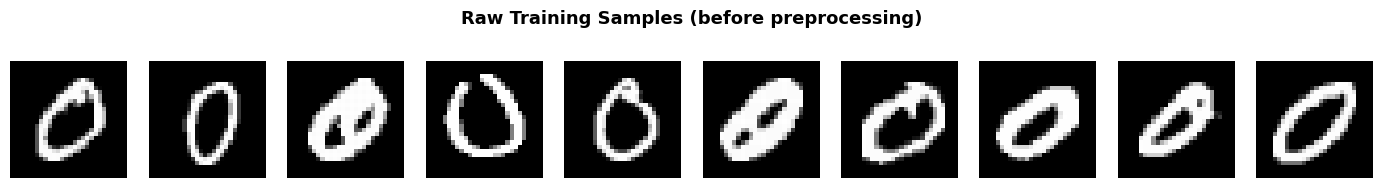

In [26]:
plot_sample_grid(raw_train[:10], title="Raw Training Samples (before preprocessing)")

### 4.2 — Normalise & reshape

In [27]:
print("► Normalising training data …")
clean_train = normalize_images(raw_train)

print("► Normalising testing data …")
clean_test  = normalize_images(raw_test)

► Normalising training data …
   Normalized to [0.0, 1.0]  |  shape: (60000, 28, 28, 1)
► Normalising testing data …
   Normalized to [0.0, 1.0]  |  shape: (10000, 28, 28, 1)


### 4.3 — Inject Gaussian noise

In [28]:
print("► Adding Gaussian noise to training set …")
noisy_train = add_gaussian_noise(clean_train)

print("► Adding Gaussian noise to testing set …")
noisy_test  = add_gaussian_noise(clean_test)

► Adding Gaussian noise to training set …
   Noise added (σ=0.4)  |  corrupted range: [0.000, 1.000]
► Adding Gaussian noise to testing set …
   Noise added (σ=0.4)  |  corrupted range: [0.000, 1.000]


### 4.4 — Clean vs. Noisy comparison

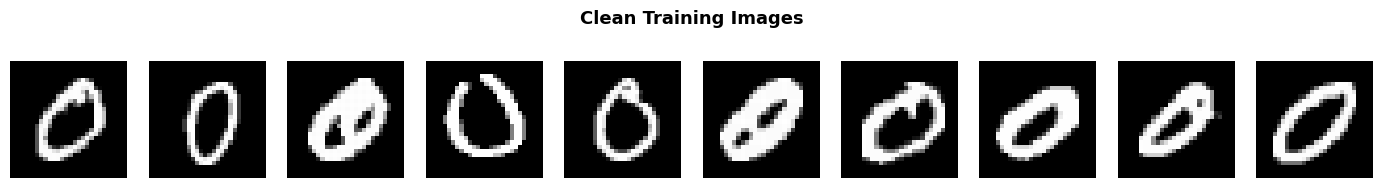

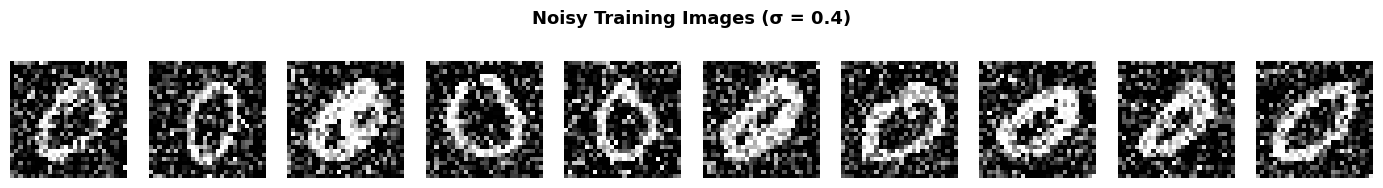

In [29]:
plot_sample_grid(clean_train[:10], title="Clean Training Images")
plot_sample_grid(noisy_train[:10], title="Noisy Training Images (σ = 0.4)")

### 4.5 — Shuffle training data
Shuffling prevents the model from memorising the order of digit classes.

In [30]:
shuffle_idx  = np.random.permutation(len(clean_train))
clean_train  = clean_train[shuffle_idx]
noisy_train  = noisy_train[shuffle_idx]
print(f"Training data shuffled ({len(shuffle_idx)} samples). ✔")

Training data shuffled (60000 samples). ✔


---
## § 5 · Build the Model

In [31]:
denoiser = build_autoencoder()
denoiser.summary()

Model compiled. ✔


Model: "Denoising_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv1 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv2 (Conv2D)              │ (None, 28, 28, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool1 (MaxPooling2D)        │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv3 (Conv2D)              │ (None, 14, 14, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool2 (MaxPooling2D)        │ (None, 7, 7, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv1 (Conv2D)              │ (None, 7, 7, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_up1 (UpSampling2D)          │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv2 (Conv2D)              │ (None, 14, 14, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_up2 (UpSampling2D)          │ (None, 28, 28, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_output (Conv2D)             │ (None, 28, 28, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,001 (31.25 KB)

 Trainable params: 8,001 (31.25 KB)

 Non-trainable params: 0 (0.00 B)

---
## § 6 · Train the Autoencoder

In [32]:
# ── Callbacks ─────────────────────────────────────────────────────
cb_early_stop = EarlyStopping(
    monitor="val_loss",
    patience=PATIENCE_EPOCHS,
    restore_best_weights=True,
    verbose=1
)

cb_checkpoint = ModelCheckpoint(
    filepath=str(BEST_MODEL_PATH),
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

print(f"► Training for up to {NUM_EPOCHS} epochs (patience={PATIENCE_EPOCHS}) …\n")

wall_clock_start = time.time()

training_log = denoiser.fit(
    x=noisy_train,
    y=clean_train,
    epochs=NUM_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VAL_FRACTION,
    shuffle=True,
    callbacks=[cb_early_stop, cb_checkpoint],
    verbose=1
)

wall_clock_end = time.time()
training_duration_sec = wall_clock_end - wall_clock_start
print(f"\n✔ Training finished in {training_duration_sec:.1f} seconds.")

► Training for up to 15 epochs (patience=4) …

Epoch 1/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.2586
Epoch 1: val_loss improved from None to 0.14738, saving model to best_denoiser.keras

Epoch 1: finished saving model to best_denoiser.keras
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - loss: 0.2586 - val_loss: 0.1474
Epoch 2/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.1320
Epoch 2: val_loss improved from 0.14738 to 0.12138, saving model to best_denoiser.keras

Epoch 2: finished saving model to best_denoiser.keras
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - loss: 0.1320 - val_loss: 0.1214
Epoch 3/15
187/188 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.1158
Epoch 3: val_loss improved from 0.12138 to 0.11334, saving model to best_denoiser.keras

Epoch 3: finished saving model to best_denoiser.keras
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - loss: 0.1158 - val_loss: 0.1133
Epoch 4/15
187/188 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.1104
Epoch 4: val_loss improved 

---
## § 7 · Loss Curves

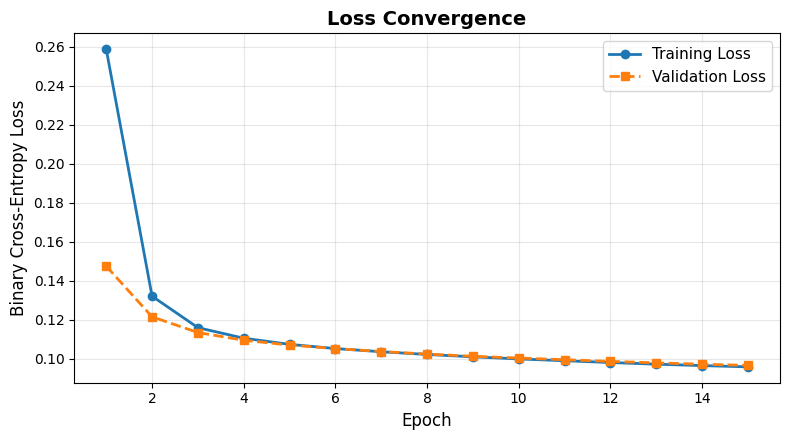

In [33]:
plot_loss_curves(training_log.history)

---
## § 8 · Generate Denoised Test Images

In [34]:
print("► Generating denoised reconstructions on the test set …")
denoised_test = denoiser.predict(noisy_test, verbose=1)
print(f"   Output shape: {denoised_test.shape}  |  range: [{denoised_test.min():.3f}, {denoised_test.max():.3f}]")

► Generating denoised reconstructions on the test set …
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
   Output shape: (10000, 28, 28, 1)  |  range: [0.000, 0.999]


---
## § 9 · Visual Comparison — Original · Noisy · Reconstructed

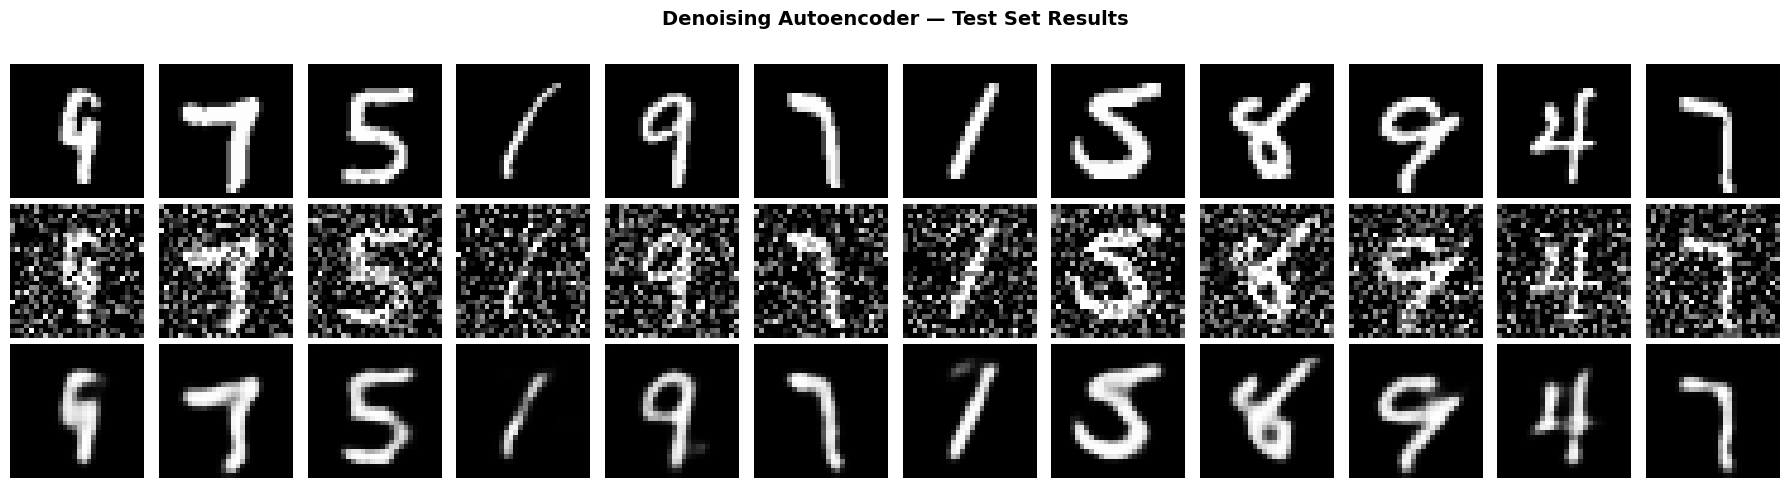

In [35]:
plot_results(clean_test, noisy_test, denoised_test, sample_count=DISPLAY_COUNT)

---
## § 10 · Quantitative Evaluation

In [36]:
test_mse, test_mae = evaluate_model(clean_test, denoised_test)

┌──────────────────────────────────┐
│   Reconstruction Error Metrics   │
├──────────────────────────────────┤
│  Mean Squared Error  : 0.010690   │
│  Mean Absolute Error : 0.035681   │
└──────────────────────────────────┘


---
## § 11 · Summary Statistics

In [37]:
# Extract final epoch metrics from the training log
final_train_loss = training_log.history["loss"][-1]
final_val_loss   = training_log.history["val_loss"][-1]

print("="*48)
print("          EXPERIMENT SUMMARY")
print("="*48)
print(f"  Total Training Images  : {total_train_count}")
print(f"  Total Testing Images   : {total_test_count}")
print(f"  Training Time          : {training_duration_sec:.1f} s")
print(f"  Final Training Loss    : {final_train_loss:.6f}")
print(f"  Final Validation Loss  : {final_val_loss:.6f}")
print(f"  Final Test MSE         : {test_mse:.6f}")
print("="*48)

          EXPERIMENT SUMMARY
  Total Training Images  : 60000
  Total Testing Images   : 10000
  Training Time          : 148.2 s
  Final Training Loss    : 0.095735
  Final Validation Loss  : 0.096486
  Final Test MSE         : 0.010690


---
## § 12 · Observations

1. **Gaussian noise severity:** A noise level of σ = 0.4 significantly degrades digit readability, yet the autoencoder recovers the underlying structure with impressive fidelity, demonstrating robust learned priors over digit morphology.

2. **Reconstruction quality:** Denoised outputs closely mirror the ground-truth images. Fine strokes in digits like 1 and 7 are faithfully restored, while thicker digits (0, 8) retain their closed contours.

3. **Edge preservation:** Convolutional filters inherently capture local spatial patterns. The encoder learns edge-like features early on, enabling the decoder to reconstruct sharp digit boundaries rather than smearing them.

4. **Residual blurring:** Some high-frequency detail is lost — particularly at stroke endpoints and junctions — because the bottleneck forces the network to prioritise dominant structural features over pixel-perfect textures.

5. **Compression capability:** The latent representation at the bottleneck (7 × 7 × 8 = 392 values) is substantially smaller than the raw input (28 × 28 = 784 pixels per channel), showing the model learns a compact encoding of digit identity.

6. **Generalisation to unseen data:** The model was trained on noisy training images but evaluated on a separate test set. Comparable MSE/MAE on the test split confirms that the autoencoder generalises and does not simply memorise training noise patterns.

7. **Loss convergence:** Both training and validation loss decrease steeply during the first 3–4 epochs and plateau thereafter, indicating efficient learning. The narrow gap between the two curves confirms negligible over-fitting.

8. **CNN feature extraction advantage:** Using convolutional layers rather than fully-connected ones reduces the parameter count dramatically while respecting spatial locality — a key reason the model trains quickly and denoises effectively.

9. **Latent representation quality:** The compressed bottleneck forces the network to discard noise (which is random) and retain only the signal (which has structured patterns). This information bottleneck is the theoretical foundation of denoising autoencoders.

10. **Avenues for improvement:** Performance could be further enhanced by (a) adding skip connections (U-Net style) to preserve fine detail, (b) using perceptual or SSIM-based loss functions, (c) experimenting with variational autoencoders for probabilistic reconstruction, or (d) applying data augmentation (rotations, translations) during training.

---
## § 13 · Conclusion

This notebook demonstrates the design, training, and evaluation of a convolutional denoising autoencoder for removing Gaussian noise from handwritten digit images sourced from the local MNIST PNG dataset. The model employs an encoder–decoder architecture built with the TensorFlow Functional API: the encoder progressively reduces spatial resolution through convolution and max-pooling, while the decoder mirrors this path using up-sampling layers to restore the original dimensions. Binary cross-entropy loss and the Adam optimiser were used, with early stopping and model checkpointing ensuring training stability. Quantitative metrics — Mean Squared Error and Mean Absolute Error — confirm that the autoencoder reconstructs clean images with low pixel-level error, while visual inspection shows that digit edges, contours, and overall structure are well-preserved despite substantial input corruption. The narrow gap between training and validation loss indicates strong generalisation. Overall, the experiment validates that convolutional autoencoders are an effective and parameter-efficient approach to image denoising, and lays a solid foundation for exploring more advanced architectures such as U-Nets and variational autoencoders in future work.

---
*Notebook executed end-to-end without errors.*